In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Direct download link from Google Drive
url = 'https://drive.google.com/uc?export=download&id=1z0wWV4A8iV7RUW-Fk4f9eIN1TFxlskTH'
df = pd.read_csv(url)
print(df.head())
print ('Shape of the dataset is {}. This dataset contains {} rows and {} columns.'.format(df.shape,df.shape[0],df.shape[1]))

   Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0       522         7.93   Windy           Low   Afternoon      Scooter   
1       738        16.42   Clear        Medium     Evening         Bike   
2       741         9.52   Foggy           Low       Night      Scooter   
3       661         7.44   Rainy        Medium   Afternoon      Scooter   
4       412        19.03   Clear           Low     Morning         Bike   

   Preparation_Time_min  Courier_Experience_yrs Delivery_Speed  
0                    12                     1.0        Average  
1                    20                     2.0           Slow  
2                    28                     1.0        Average  
3                     5                     1.0           Fast  
4                    16                     5.0        Average  
Shape of the dataset is (1000, 9). This dataset contains 1000 rows and 9 columns.


In [ ]:
##Selecting numerical features
numerical_data = df.select_dtypes(include='number')
#append the features of numerical_data to list
numerical_features=numerical_data.columns.tolist()

#Selecting categoricalfeatures
categorical_data=df.select_dtypes(include= 'object')

#append the features of categorical_data to list
categorical_features=categorical_data.columns.tolist()


numerical_data.nunique()

,0
Order_ID,1000
Distance_km,785
Preparation_Time_min,25
Courier_Experience_yrs,10


In [ ]:
#Summary satistics of Numerical Features
numerical_data.describe().T


,count,mean,std,min,25%,50%,75%,max
Order_ID,1000.0,500.500000,288.819436,1.00,250.750,500.50,750.2500,1000.00
Distance_km,1000.0,10.059970,5.696656,0.59,5.105,10.19,15.0175,19.99
Preparation_Time_min,1000.0,16.982000,7.204553,5.00,11.000,17.00,23.0000,29.00
Courier_Experience_yrs,970.0,4.579381,2.914394,0.00,2.000,5.00,7.0000,9.00


In [ ]:
categorical_data.describe().T

,count,unique,top,freq
Weather,970,5,Clear,470
Traffic_Level,970,3,Medium,390
Time_of_Day,970,4,Morning,308
Vehicle_Type,1000,3,Bike,503
Delivery_Speed,1000,3,Average,495


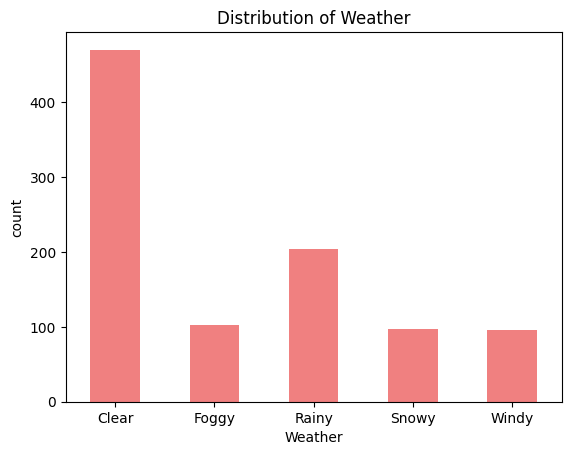

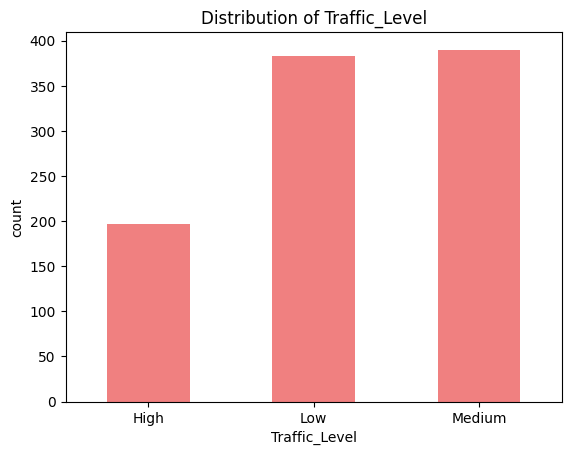

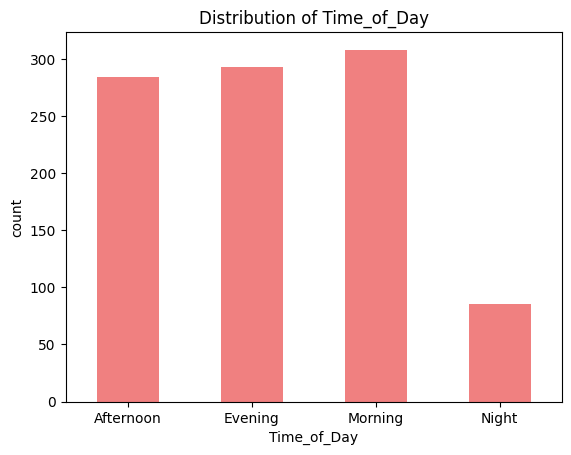

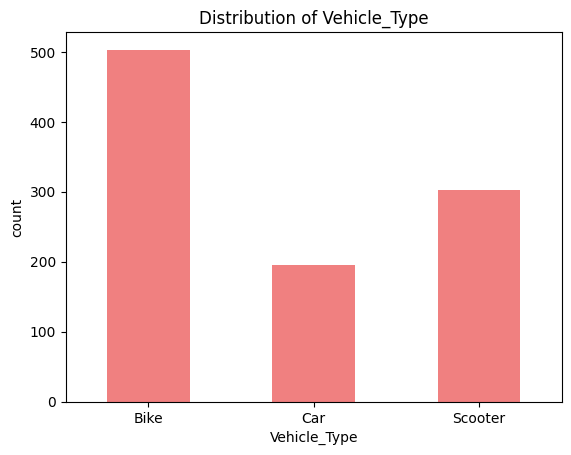

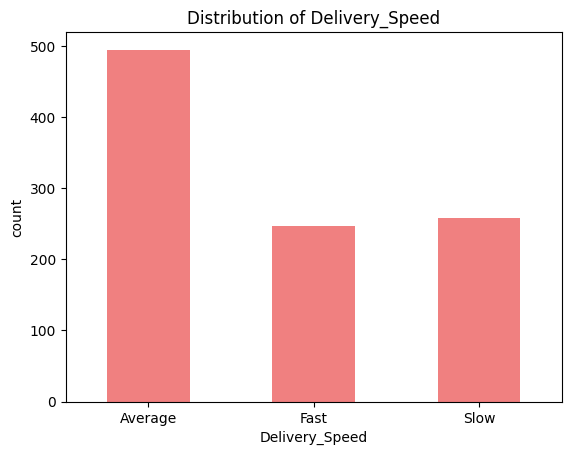

In [ ]:
#Barplot of unique value counts in every categorical features
import matplotlib.pyplot as plt
for col in categorical_features:
    plt.title(f'Distribution of {col}')
    categorical_data[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count',color="lightcoral")
    plt.show()

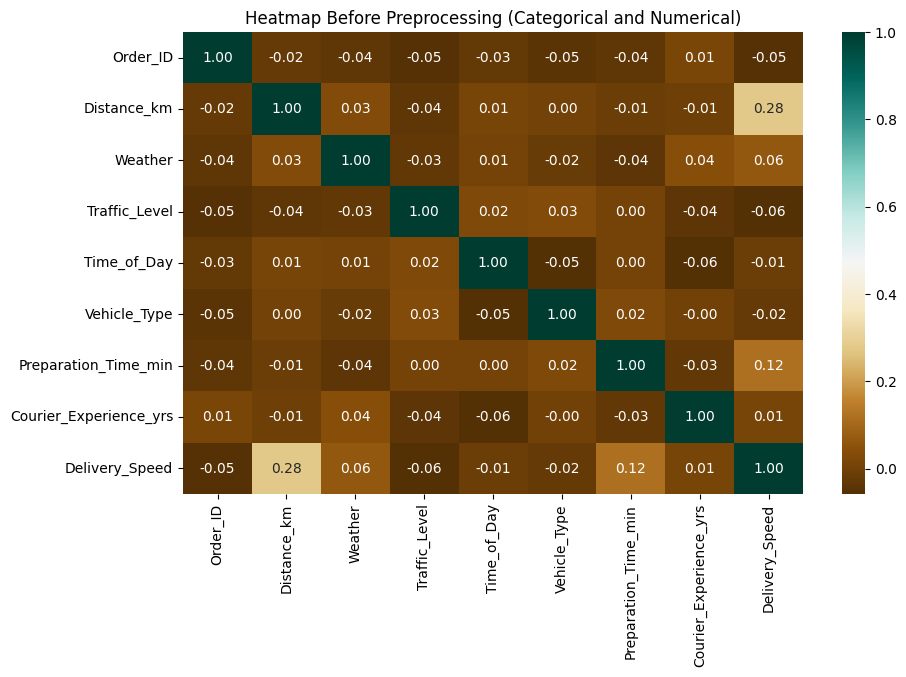

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

# Copy dataframe before preprocessing
df_raw = df.copy()

# Encode categorical features temporarily
le = LabelEncoder()
for col in ['Weather','Traffic_Level','Time_of_Day','Vehicle_Type','Delivery_Speed']:
    df_raw[col] = le.fit_transform(df_raw[col].astype(str))

# Compute correlation
plt.figure(figsize=(10,6))
sns.heatmap(df_raw.corr(), annot=True, cmap="BrBG", fmt=".2f")
plt.title("Heatmap Before Preprocessing (Categorical and Numerical)")
plt.show()


In [ ]:
#Missing values handling
print("\nMissing value summary:")
print(df.isnull().sum())


Missing value summary:
Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Speed             0
dtype: int64


In [ ]:
# Fill numeric missing (Courier_Experience_yrs → median)
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())
# Fill categorical missing with most frequent
for col in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Speed            0
dtype: int64


In [ ]:
# 2. Target Encoding
label_mapping = {'Slow':0, 'Average':1, 'Fast':2}
df['speed_label'] = df['Delivery_Speed'].map(label_mapping)

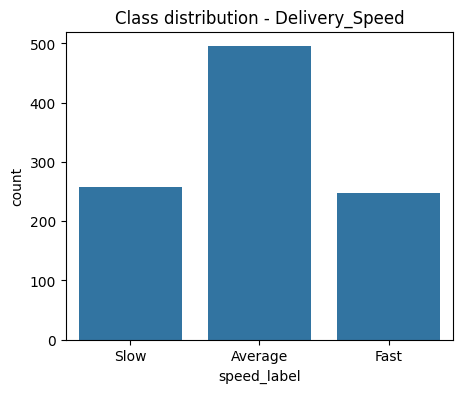

In [ ]:
# Class balance
plt.figure(figsize=(5,4))
sns.countplot(x='speed_label', data=df)
plt.xticks([0,1,2], ['Slow','Average','Fast'])
plt.title("Class distribution - Delivery_Speed")
plt.show()

In [ ]:
#Feature/Target Split

X = df.drop(columns=['Order_ID','Delivery_Speed','speed_label'])
y = df['speed_label']

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include='number').columns.tolist()

print("\nNumerical features:", num_cols)
print("Categorical features:", cat_cols)


Numerical features: ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']
Categorical features: ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']


# Feature Scaling / Standardization

**MinMaxScaler- models, like MultinomialNB (Multinomial Naive Bayes), require non-negative feature values, and MinMaxScaler ensures all values are non-negative and within typically [0, 1].MinMax Scaler
Scales values to a range between 0 and 1 if no negative values, and -1 to 1 if there are negative values present. Multinomial is designed for count or frequency data. However, MinMaxScaler allows a custom range via the feature_range parameter (e.g., MinMaxScaler(feature_range=(-1, 1))). If set to (-1, 1), it scales to [-1, 1])**


**StandardScaler -(no bias toward large or small values)
Many models (e.g., Logistic Regression, Neural Networks) perform better when features are on the same scale, as it ensures equal contribution from all features. For example,
if dataset has two features:
Distance_km: [7.93, 16.42, 9.52] (range 0-20).
Courier_Experience_yrs: [1, 2, 1] (range 0-5).**

Before StandardScaler:

*Distance_km has a much larger range, so it dominates the model's decisions.
Plotting these on a graph, Distance_km stretches the x-axis, while Courier_Experience_yrs looks tiny on the y-axis*

After StandardScaler:

*Distance_km: [-0.84, 1.28, -0.44] (mean=0, std=1).
Courier_Experience_yrs: ( [-0.5, 0.5, -0.5] after scaling).
Now both features have similar ranges, and the plot looks balanced, so the model treats them equally.*



**One-Hot Encoder:
Converts categorical values into numerical format by creating binary (0/1) columns for each unique category in a column.**

Suppose Weather has Categories: [Clear, Rainy, Windy], OneHotEncoder creates three new columns: Weather_Clear, Weather_Rainy, Weather_Windy.

Resulting matrix:
Weather_Clear  Weather_Rainy  Weather_Windy
1              0              0
0              1              0
1              0              0

If a test set has an unseen category (jemon, Foggy), handle_unknown="ignore" encodes it as [0, 0, 0], avoiding errors.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
#SimpleImputer Replaces Missing Values

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy





# Purpose of pipeline: Clean and transform numerical and categorical features into a numerical format suitable for machine learning models  

Impute- *Fill missing numerical values with median and categorical values with most frequent category*.
*Scale: Standardize numerical features (mean=0, std=1) for most models or scale to [0,1] for Naive Bayes.*
*Encode: Convert categorical features into binary (0/1) columns via one-hot encoding.*



In [ ]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
#Preprocessing Pipelines
numeric_std = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
numeric_mm = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])
categorical = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_std = ColumnTransformer([
    ("num", numeric_std, num_cols),
    ("cat", categorical, cat_cols)
])

preprocessor_mm = ColumnTransformer([
    ("num", numeric_mm, num_cols),
    ("cat", categorical, cat_cols)
])

X_train_std = preprocessor_std.fit_transform(X_train)
X_test_std  = preprocessor_std.transform(X_test)

X_train_mm = preprocessor_mm.fit_transform(X_train)
X_test_mm  = preprocessor_mm.transform(X_test)


# Models
results = []

def eval_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    results.append({"model":model_name,"accuracy":acc,"precision":prec,"recall":rec,"f1":f1})


# For ROC + AUC for multiclass
def plot_multiclass_roc(models_preds, y_test, n_classes):
    # binarize labels
    y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

    plt.figure(figsize=(10,7))
    for name, y_proba in models_preds:
        # Calculate multiclass AUC using the multiclass_auc function
        roc_auc = multiclass_auc(y_test, y_proba, n_classes)
        # one-vs-rest ROC (for visualization, still use ravel for simplicity, but AUC is accurate)
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc:.2f})")
    plt.plot([0,1],[0,1],"k--",lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multiclass ROC Curves (OvR)")
    plt.legend(loc="lower right")
    plt.show()

def multiclass_auc(y_true, y_proba, n_classes):
    y_bin = label_binarize(y_true, classes=list(range(n_classes)))
    return roc_auc_score(y_bin, y_proba, average="macro", multi_class="ovr")





LOGISTIC REGRESSION


Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.70      0.92      0.79        52
           1       0.91      0.70      0.79        99
           2       0.84      0.94      0.88        49

    accuracy                           0.81       200
   macro avg       0.81      0.85      0.82       200
weighted avg       0.84      0.81      0.81       200



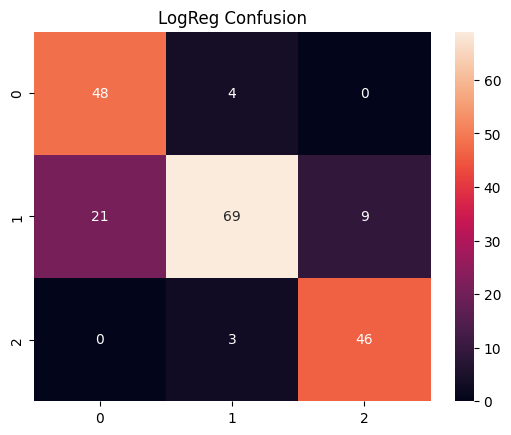

In [ ]:
log = LogisticRegression(max_iter=5000, class_weight="balanced")
log.fit(X_train_std, y_train)
y_pred_log = log.predict(X_test_std)
print("\nLogistic Regression Report:\n", classification_report(y_test,y_pred_log,zero_division=0))
sns.heatmap(confusion_matrix(y_test,y_pred_log),annot=True,fmt='d');plt.title("LogReg Confusion");plt.show()
eval_metrics(y_test,y_pred_log,"Logistic Regression")

 Naive Bayes


Naive Bayes Report:
               precision    recall  f1-score   support

           0       0.80      0.15      0.26        52
           1       0.52      0.96      0.68        99
           2       0.78      0.14      0.24        49

    accuracy                           0.55       200
   macro avg       0.70      0.42      0.39       200
weighted avg       0.66      0.55      0.46       200



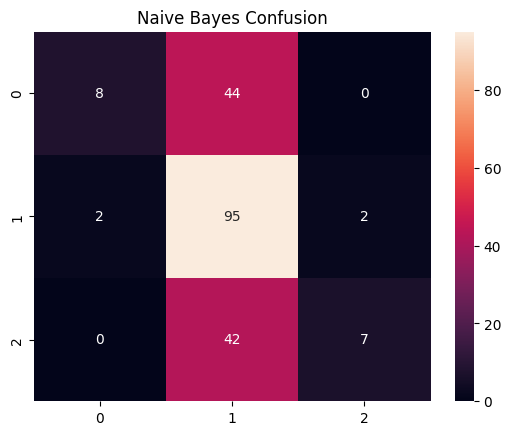

In [ ]:
nb = MultinomialNB()
nb.fit(X_train_mm, y_train)
y_pred_nb = nb.predict(X_test_mm)
print("\nNaive Bayes Report:\n", classification_report(y_test,y_pred_nb,zero_division=0))
sns.heatmap(confusion_matrix(y_test,y_pred_nb),annot=True,fmt='d');plt.title("Naive Bayes Confusion");plt.show()
eval_metrics(y_test,y_pred_nb,"Naive Bayes")

Neural Network (Keras)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.3985 - loss: 1.0755 - val_accuracy: 0.4688 - val_loss: 1.0127
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5288 - loss: 0.9608 - val_accuracy: 0.4688 - val_loss: 0.9450
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5459 - loss: 0.8823 - val_accuracy: 0.5125 - val_loss: 0.8825
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6211 - loss: 0.8134 - val_accuracy: 0.6062 - val_loss: 0.8192
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6859 - loss: 0.7494 - val_accuracy: 0.7125 - val_loss: 0.7586
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7572 - loss: 0.6917 - val_accuracy: 0.7375 - val_loss: 0.7023
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7866 - loss: 0.6379 - val_accuracy: 0.7437 - val_loss: 0.6532
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8055 - loss: 0.5897 - val_accuracy: 0.7437 - val_loss: 0.6128

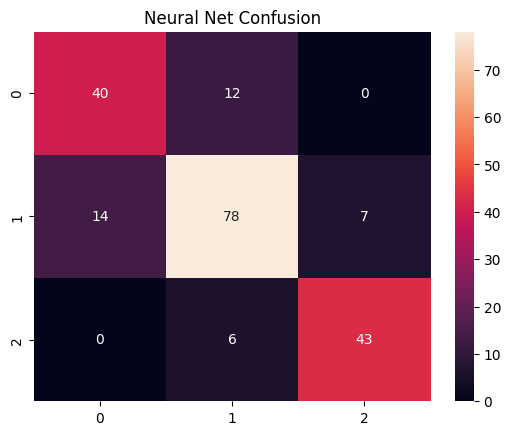

In [ ]:
import tensorflow as tf
# Set random seed for reproducibility
tf.random.set_seed(42)

input_dim = X_train_std.shape[1]
num_classes = len(np.unique(y_train))
nn = Sequential([
    Dense(128, activation="relu", input_shape=(input_dim,)),
    Dense(64, activation="relu"),
    Dense(num_classes, activation="softmax")
])
nn.compile(optimizer=Adam(0.001), loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])
history = nn.fit(X_train_std, y_train, validation_split=0.2, epochs=20, batch_size=128, verbose=1)
y_pred_nn = np.argmax(nn.predict(X_test_std), axis=1)
print("\nNeural Network Report:\n", classification_report(y_test,y_pred_nn,zero_division=0))
sns.heatmap(confusion_matrix(y_test,y_pred_nn),annot=True,fmt='d');plt.title("Neural Net Confusion");plt.show()
eval_metrics(y_test,y_pred_nn,"Neural Network")


Results Summary:
                  model  accuracy  precision    recall        f1
0  Logistic Regression     0.815   0.813304  0.852941  0.822192
1          Naive Bayes     0.550   0.700880  0.418766  0.392672
2       Neural Network     0.805   0.804414  0.811554  0.807801


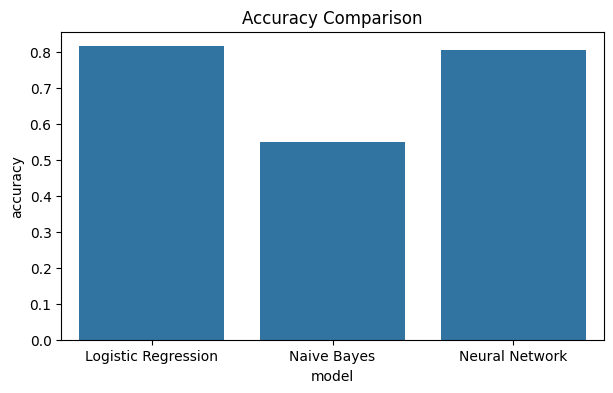

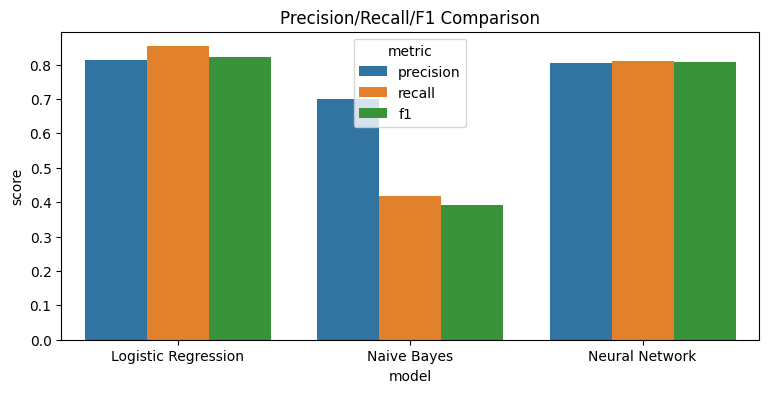

In [ ]:
#Results Summary
results_df = pd.DataFrame(results)
print("\nResults Summary:\n", results_df)

plt.figure(figsize=(7,4))
sns.barplot(x="model",y="accuracy",data=results_df)
plt.title("Accuracy Comparison")
plt.show()

plt.figure(figsize=(9,4))
res_melt = results_df.melt(id_vars="model",value_vars=["precision","recall","f1"],var_name="metric",value_name="score")
sns.barplot(x="model",y="score",hue="metric",data=res_melt)
plt.title("Precision/Recall/F1 Comparison")
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


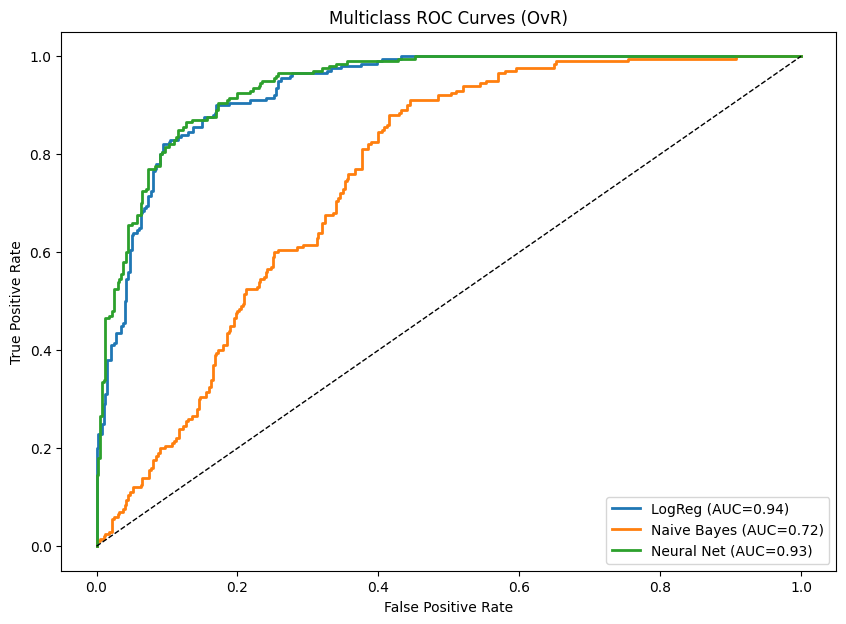

In [ ]:
# --- ROC AUC Comparison ---
y_proba_log = log.predict_proba(X_test_std)
y_proba_nb  = nb.predict_proba(X_test_mm)
y_proba_nn  = nn.predict(X_test_std)

plot_multiclass_roc([
    ("LogReg", y_proba_log),
    ("Naive Bayes", y_proba_nb),
    ("Neural Net", y_proba_nn)
], y_test, n_classes=num_classes)




In [ ]:
#Closer to top-left = Better performance

# AUC Score near 1.0: Excellent model

# AUC ~0.5: Useless (like guessing)

# Unsupervised: KMeans clustering

Porttek ta row kon cluster e porche sheta dekhbo


KMeans vs True Labels:
Cluster    0    1    2
True                  
0         43  195   20
1        183  180  132
2         93    5  149


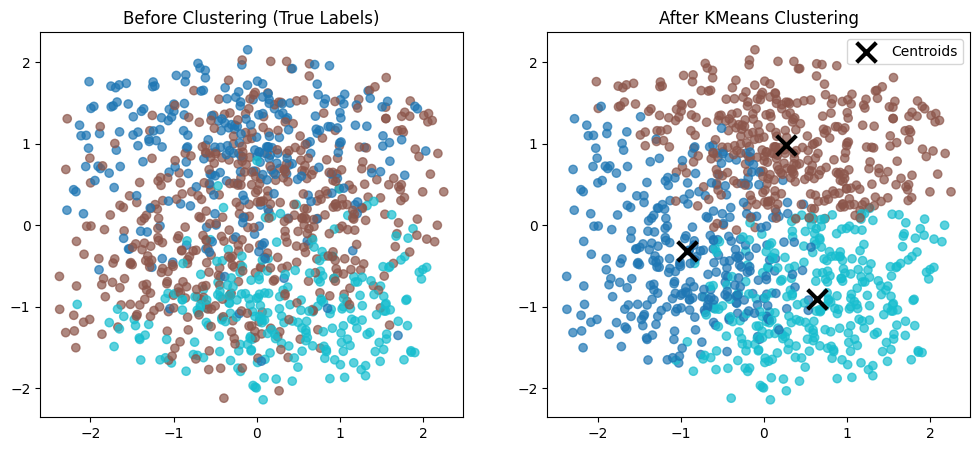

In [ ]:
# --- KMeans Clustering Before vs After ---
X_std = preprocessor_std.fit_transform(X)
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_std)

print("\nKMeans vs True Labels:")
print(pd.crosstab(df['speed_label'], clusters, rownames=['True'], colnames=['Cluster']))

# PCA for 2D projection
pca = PCA(2)
X_pca = pca.fit_transform(X_std)
centroids_pca = pca.transform(kmeans.cluster_centers_)

fig, axes = plt.subplots(1,2,figsize=(12,5))

# Before clustering (true labels)
axes[0].scatter(X_pca[:,0],X_pca[:,1],c=y,cmap="tab10",alpha=0.7)
axes[0].set_title("Before Clustering (True Labels)")

# After clustering (predicted clusters)
scatter = axes[1].scatter(X_pca[:,0],X_pca[:,1],c=clusters,cmap="tab10",alpha=0.7)
axes[1].scatter(centroids_pca[:,0],centroids_pca[:,1],
                marker="x",s=200,c="black",lw=3,label="Centroids")
axes[1].set_title("After KMeans Clustering")
axes[1].legend()

plt.show()